# Python Notebook to demonstrate Vibration Mode Recognition Using A Combination Of DSP And Machine Learning

## This example supports an arbitrary number of categories and features

This program downloads an arbitrary number of .wav file recordings of rotating machines, displaying four different vibration modes, it then uses a subset of data from each file to train a Convolutional Neural Network (CNN) to recognize the different vibration modes then tests the model using a further subset of the data.

.wav file recordings can be downloaded from a website URL (GitHub Raw User Content) or copied from Google Drive /wav_files folder.

Prior to the CNN, the time domain vibration data is converted to the frequency domain. This allows a drastic reduction in the complexity of the CNN.

This file trains and tests the model, it also generates a Tensorflow Lite model, with 8 bit quantization, runs the model on the test sequence and prints the results.

The CNN architecture is shown in the following image. It has 128 input nodes, which are the 128 frequency domain coefficients between D.C. and the Nyquist frequency, for the 256 sample input frame of the time domain sequence. It has an output node for each classification category.

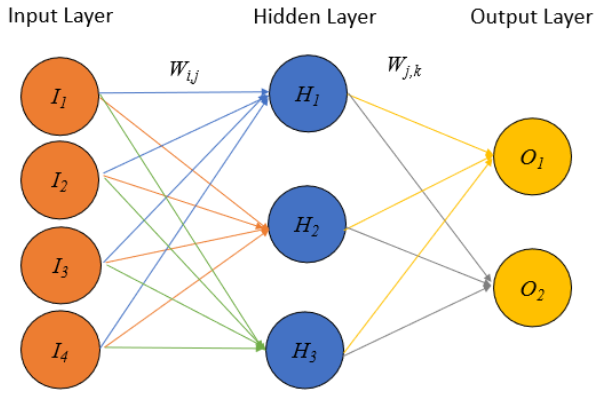

SigLib DSP Library can be downloaded from: https://github.com/Numerix-DSP/siglib

Sigma Numerix Ltd. Machine Learning capabilities are summarized here: https://numerix-dsp.com/ai/

**License**

This program is free software: you can redistribute it and/or modify 
it under the terms of the GNU General Public License as published by 
the Free Software Foundation, version 3.

This program is distributed in the hope that it will be useful, but 
WITHOUT ANY WARRANTY; without even the implied warranty of 
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU 
General Public License for more details.
 
You should have received a copy of the GNU General Public License 
along with this program. If not, see <http://www.gnu.org/licenses/>.

Copyright © 2026 Delta Numerix All rights reserved.


In [1]:
import numpy as np
import tensorflow as tf
import os

from matplotlib import pyplot as plt
from scipy.io import wavfile
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix


2026-03-09 10:28:04.465174: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 10:28:04.674804: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Top level configuration

# .wav file sampling rate = 16 kHz
# Frame size = 256 samples
# Frame period = 16 ms

timeDomainFrameLength = 256
networkInputLayerNodes = timeDomainFrameLength >> 1

# Download the .wav files from the SigLib GitHub repository
masterUrlRoot = 'https://raw.githubusercontent.com/Numerix-DSP/siglib/main/Examples/CExamples/MachineLearning/sourceData/'

# Input filenames:
wavFilenames = [
  'Machine1.wav',
  'Machine2.wav',
  # 'Machine3.wav',
  # 'Machine4.wav',
]

numClasses = len(wavFilenames)
print (f'numClasses: {numClasses}')


numClasses: 2


In [3]:
# Load .wav files and create a list containing all wav datasets

wavData = []
for i in range(0, numClasses):
  if (os.path.exists(wavFilenames[i]) != True):          # If files are stored locally, we can skip this
    fileurl = masterUrlRoot + wavFilenames[i]
    print(f'Loading fileurl: {fileurl}')
    if 'https://' in fileurl:
      !wget -arg1 $fileurl
    else:
      !cp $fileurl .
  sampleRate, wd = wavfile.read(wavFilenames[i])
  wavData.append(wd)
  print(f'len(wavData{i}): {len(wavData[i])}')
  print(f'Sample Rate: {sampleRate}')


len(wavData0): 3023499
Sample Rate: 16000
len(wavData1): 2852709
Sample Rate: 16000


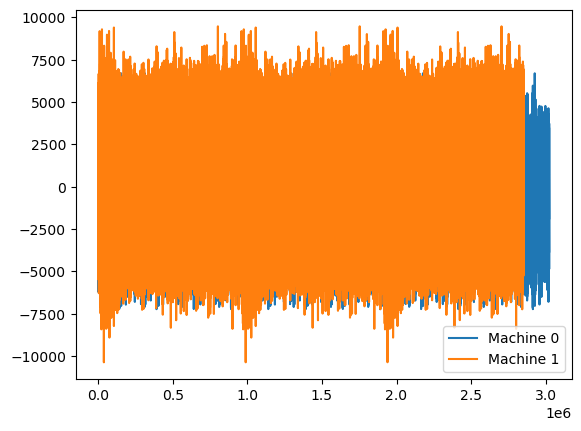

In [4]:
# Plot data to verify it

plt.figure()
for i in range(0, numClasses):
  plt.plot(wavData[i], label=f'Machine {i}')
plt.legend(loc="best")
plt.show()
plt.close()


In [5]:
# Create a list of Numpy 2D arrays from waveforms
# Limit the dataset lengths to modulo timeDomainFrameLength

wav_2D_list = []
for i in range(0, numClasses):
  maxIndex = (len(wavData[i])//timeDomainFrameLength)*timeDomainFrameLength
  wavData[i] = wavData[i][:maxIndex]
  wav_2D_list.append(np.reshape(wavData[i], (-1, timeDomainFrameLength)))
  print(f'wav_2D_list[{i}] shape: {wav_2D_list[i].shape}')

# print(wav_2D_list)


wav_2D_list[0] shape: (11810, 256)
wav_2D_list[1] shape: (11143, 256)


In [6]:
# Perform DSP Pre-processing on subframes
# Pre-process function for translating data from time to frequency domain
# This function processes a single waveform, which is a 2D Numpy array, with each row being the FFT length
def pre_process(wav_2D_array):
  window = np.blackman(timeDomainFrameLength)

              # Create empty frequency domain Numpy array
  wav_fftd_2D_array = np.empty(shape=[0, networkInputLayerNodes])

  # print(len(wav_2D_array))
  for i in range(len(wav_2D_array)):
    windowed = wav_2D_array[i] * window

            # Real to Real FFT and normalize for FFT scaling
    fftd = np.fft.fft(windowed, timeDomainFrameLength) / (timeDomainFrameLength/2.0)
    fftd = np.abs(fftd.real)

            # Truncate output to only include selected frequency domain coefficients from D.C. to Nyquist frequency
    fftd = fftd[0:networkInputLayerNodes]
    wav_fftd_2D_array = np.append(wav_fftd_2D_array, np.reshape(fftd, (-1, networkInputLayerNodes)), axis=0)
  return (wav_fftd_2D_array)


In [7]:
# Process each dataset from the list individually - each dataset in the list is a 2D Numpy array, with each row being the FFT length
wav_fftd_2D_list = []
for i in range(0, numClasses):
  wav_fftd_2D_list.append(pre_process (wav_2D_list[i]))
  print(f'wav_fftd_2D_list[{i}] shape: {wav_fftd_2D_list[i].shape}')


wav_fftd_2D_list[0] shape: (11810, 128)
wav_fftd_2D_list[1] shape: (11143, 128)


In [8]:
# Split into training/validation (90%) and testing (10%) datasets

def split_array_train_test(wav_array, train_percentage):
  train_len = (len(wav_array) * (train_percentage)) // 100
  return wav_array[:train_len], wav_array[train_len:]

wav_xtrain = []
wav_xtest = []
for i in range(0, numClasses):
  wr, wt = split_array_train_test (wav_fftd_2D_list[i], 90)
  wav_xtrain.append(wr)
  wav_xtest.append(wt)

  print(f'wav{i} # subframes: {len(wav_fftd_2D_list[i])}')
  print(f'wav{i} train shape: {wav_xtrain[i].shape}')
  print(f'wav{i} test shape: {wav_xtest[i].shape}')


wav0 # subframes: 11810
wav0 train shape: (10629, 128)
wav0 test shape: (1181, 128)
wav1 # subframes: 11143
wav1 train shape: (10028, 128)
wav1 test shape: (1115, 128)


In [9]:
# Create X and Y datasets for training, testing and validation

X_train = wav_xtrain[0]
X_test = wav_xtest[0]
for i in range(1, numClasses):
  X_train = np.concatenate((X_train, wav_xtrain[i]), axis=0)
  X_test = np.concatenate((X_test, wav_xtest[i]), axis=0)

# Create labels
wav_ytrain = []
wav_ytest = []
for i in range(0, numClasses):
  wav_ytrain.append(np.full(len(wav_xtrain[i]), i))
  wav_ytest.append(np.full(len(wav_xtest[i]), i))

y_train = wav_ytrain[0]
y_test = wav_ytest[0]
for i in range(1, numClasses):
  y_train = np.concatenate((y_train, wav_ytrain[i]), axis=0)
  y_test = np.concatenate((y_test, wav_ytest[i]), axis=0)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')


X_train shape: (20657, 128)
y_train shape: (20657,)
X_test shape: (2296, 128)
y_test shape: (2296,)


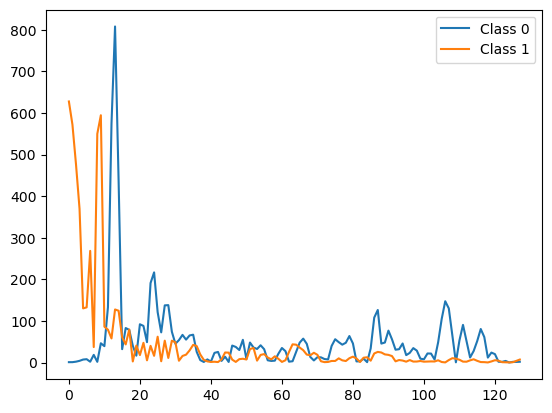

In [10]:
# Plot an arbitrary frame (100) of each class
# Don't plot first frame because there may be some zero padding in the source file

plt.figure()
for c in range(numClasses):
  c_X_train = X_train[y_train == c]
  plt.plot(c_X_train[100], label="Class " + str(c))
plt.legend(loc="best")
plt.show()
plt.close()


In [11]:
# Reshape for Keras

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')


X_train shape: (20657, 128, 1)
X_test shape: (2296, 128, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1, 32)          │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,194 (16.38 KB)

 Trainable params: 4,194 (16.38 KB)

 Non-trainable params: 0 (0.00 B)

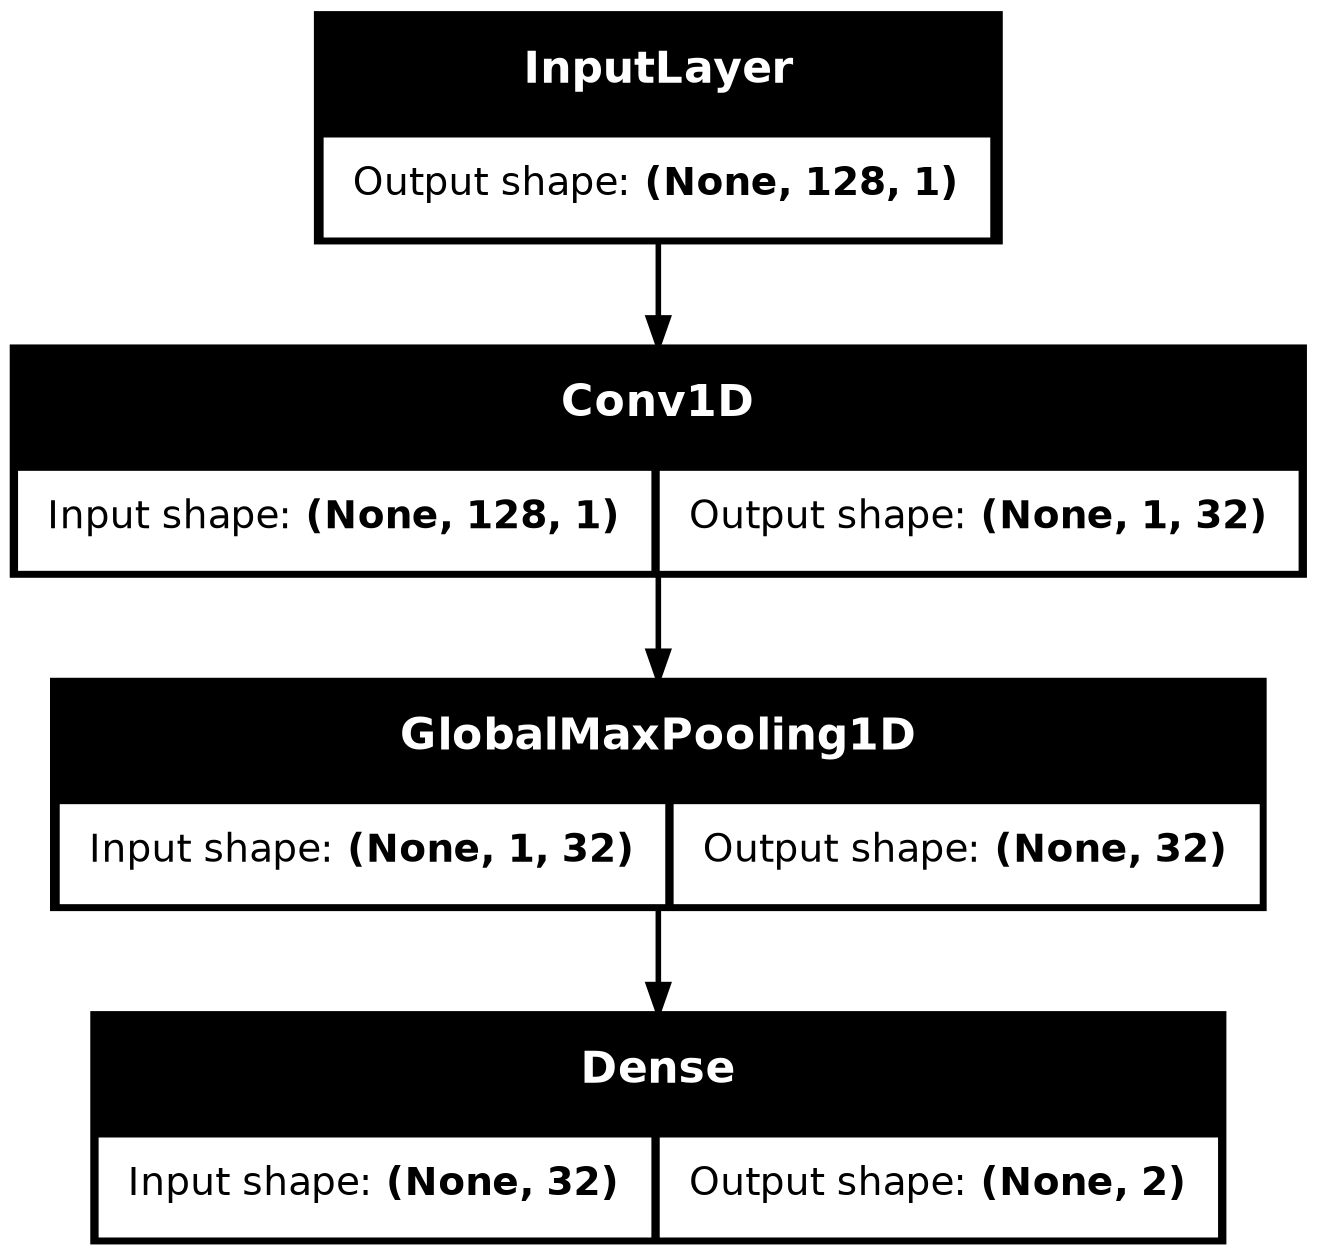

In [12]:
# Time Series Classification Model
input_layer = tf.keras.layers.Input(shape=(networkInputLayerNodes,1))
x = tf.keras.layers.Conv1D(filters=32,
                           kernel_size=networkInputLayerNodes,
                           activation='relu',
                           use_bias=True)(input_layer)
x = tf.keras.layers.GlobalMaxPooling1D()(x)  # or GlobalAveragePooling1D(), or Flatten()
output_layer = tf.keras.layers.Dense(numClasses,
                                    #  activation="sigmoid",
                                     activation="softmax",
                                     use_bias=True)(x)

model_tsc = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

model_tsc.summary()
tf.keras.utils.plot_model(model_tsc, show_shapes=True)


In [13]:
# Train the model

callbacks = [
  tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_loss")
]
model_tsc.compile(
  optimizer="adam",
  loss="sparse_categorical_crossentropy",
  metrics=["sparse_categorical_accuracy"])
history = model_tsc.fit(
  X_train,
  y_train,
  batch_size=32,
  epochs=4,
  shuffle=True,
  callbacks=callbacks,
  validation_split=0.2,
  verbose=1)


Epoch 1/4
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1926 - sparse_categorical_accuracy: 0.9820

517/517 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0315 - sparse_categorical_accuracy: 0.9969 - val_loss: 0.0014 - val_sparse_categorical_accuracy: 0.9998
Epoch 2/4
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.5623e-05 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0024 - val_sparse_categorical_accuracy: 0.9995
Epoch 3/4
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 4.6944e-07 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0023 - val_sparse_categorical_accuracy: 0.9995
Epoch 4/4
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2.9566e-07 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0022 - val_sparse_categorical_accuracy: 0.9995


In [14]:
# Test the model

model_tsc = tf.keras.models.load_model("best_model.h5")
test_loss, test_acc = model_tsc.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')
print(f'Test loss:     {test_loss}')


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3085e-04 - sparse_categorical_accuracy: 1.0000
Test accuracy: 1.0
Test loss:     0.00023084547137841582


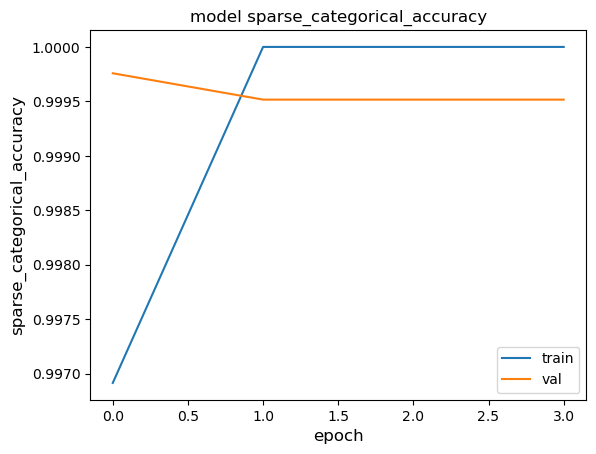

In [15]:
# Plot the accuracy as the CNN trains

metric = "sparse_categorical_accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.rcParams["figure.figsize"] = 12,5
plt.show()
plt.close()


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
y_pred shape: (2296, 2)
y_test shape: (2296,)
y_pred shape: (2296,)


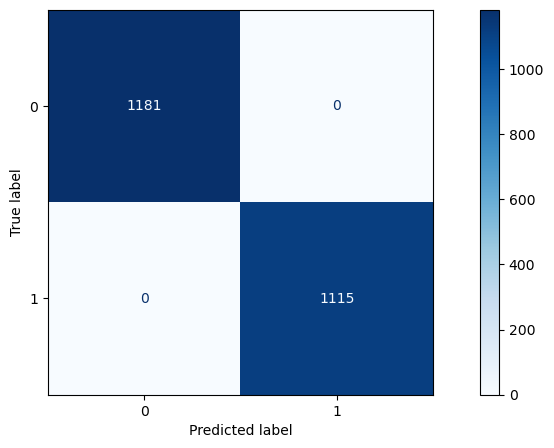

In [16]:
# Generate a confusion matrix to see which classes perform well or poorly
y_pred = model_tsc.predict(X_test)          # Returns probabilities

print(f'y_pred shape: {y_pred.shape}')

y_pred = np.argmax(y_pred, axis=-1)         # Return the index of the prediction with highest probability
print(f'y_test shape: {y_test.shape}')
print(f'y_pred shape: {y_pred.shape}')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.rcParams["figure.figsize"] = 12,5
plt.show()


In [17]:
# Convert to a Tensorflow Lite model for deployment on a microcontroller

converter = tf.lite.TFLiteConverter.from_keras_model(model_tsc)
converter.target_spec.supported_ops = [ tf.lite.OpsSet.TFLITE_BUILTINS ]       # enable TensorFlow Lite ops.
tflite_model = converter.convert()
open("tsc.tflite", "wb").write(tflite_model)


INFO:tensorflow:Assets written to: /tmp/tmpqksjx5zc/assets


INFO:tensorflow:Assets written to: /tmp/tmpqksjx5zc/assets


Saved artifact at '/tmp/tmpqksjx5zc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140542107528912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140542107518352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140542107528720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140542107527760: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1773052142.006745   63990 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1773052142.006925   63990 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-09 10:29:02.007392: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpqksjx5zc
2026-03-09 10:29:02.007783: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-09 10:29:02.007792: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpqksjx5zc
I0000 00:00:1773052142.015686   63990 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-03-09 10:29:02.017399: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-09 10:29:02.038595: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpqksjx5zc
2026-03-09 10:29:02.044613: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

19580

In [18]:
# Generate a quantized Tensorflow Lite model

def representative_data_gen():
  for input_value in tf.data.Dataset.from_tensor_slices(X_train.astype('float32')).batch(1).take(100):
    yield [input_value]

converter = tf.lite.TFLiteConverter.from_keras_model(model_tsc)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]     # If any ops can't be quantized the converter throws an error
converter.inference_input_type = tf.uint8           # Input and output tensor format
converter.inference_output_type = tf.uint8

tflite_model_quant = converter.convert()
open("tsc_quant.tflite", "wb").write(tflite_model_quant)


INFO:tensorflow:Assets written to: /tmp/tmp22_orc6i/assets


INFO:tensorflow:Assets written to: /tmp/tmp22_orc6i/assets


Saved artifact at '/tmp/tmp22_orc6i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140542107528912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140542107518352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140542107528720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140542107527760: TensorSpec(shape=(), dtype=tf.resource, name=None)


/home/johne/anaconda3/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1773052142.441418   63990 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1773052142.441474   63990 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-09 10:29:02.441719: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp22_orc6i
2026-03-09 10:29:02.442498: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-09 10:29:02.442513: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp22_orc6i
2026-03-09 10:29:02.445608: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-09 10:29:02.464658: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp22

8536

In [19]:
interpreter = tf.lite.Interpreter(model_path="tsc_quant.tflite")    # Load tensorflow lite model
interpreter.allocate_tensors()                      # Allocate tensors

input_details = interpreter.get_input_details()     # Get input and output tensor details
output_details = interpreter.get_output_details()

error_count = 0
num_test_sequences = X_test.shape[0]
print(f'num_test_sequences: {num_test_sequences}')
print(f'Max: {np.amax(X_test)}')
print(f'Min: {np.amin(X_test)}')

for i in range(0, num_test_sequences):
  X_temp=X_test[i].reshape(1, 128, 1) / 10.       # Reshape each frame for interpreting and scale for 8 bit
  input_data = np.array(X_temp, dtype=np.uint8)
  interpreter.set_tensor(input_details[0]['index'], input_data)
  interpreter.invoke()

  output_data = interpreter.get_tensor(output_details[0]['index'])    # Return a copy of the tensor data
  maxIndex = np.argmax(output_data)              # Get category with highest probability
  if (maxIndex != y_test[i]):
      error_count += 1

print(f'error_count:   {error_count}')
print(f'Test accuracy: {(num_test_sequences-error_count)*100./num_test_sequences}')
print(f'Test loss:     {(error_count)*100./num_test_sequences}')


/home/johne/anaconda3/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


num_test_sequences: 2296
Max: 1869.3379764699182
Min: 4.759140245624849e-05
error_count:   2
Test accuracy: 99.91289198606272
Test loss:     0.08710801393728224


In [ ]:
from keras_flops import get_flops

# Calculae FLOPS
flops = get_flops(model_tsc, batch_size=1)
print(f"flops: {flops}")


NameError: name 'get_flops' is not defined